# Exploratory Data Analysis

In [ ]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
import pandas as pd
# pip install pyarrow

## Objective: Next-Day Return Prediction

- Goal: Train a machine learning model to predict whether a stock will increase by at least 1% on the next trading day, using information from the S&P 500 and its constituent companies.

- Description: The model leverages technical indicators, price action, volume dynamics, volatility measures, and lagged features to identify short-term market patterns that precede positive price movements over a one-day horizon. The task is framed as a binary classification problem, where the target variable indicates whether the next-day return exceeds the 1% threshold.

- Purpose: To evaluate the feasibility of very short-term return prediction using historical market data while strictly avoiding look-ahead bias and preserving the temporal structure of financial time series.

## Data Origin and Description

The data for this project comes from Kaggle, specifically the Advanced Stock Dataset by baidalinadilzhan, which is built using historical data retrieved from the Yahoo Finance API and covers approximately the past five years of trading for companies in the S&P 500 index. The dataset is structured with daily adjusted prices that account for corporate actions such as dividends and stock splits, making it suitable for financial analysis and time-series modeling.

The full dataset includes over 620,000 daily observations with 73 engineered features, including opening, high, low, and closing prices, trading volume, technical indicators (e.g., moving averages, RSI), volatility measures, and multiple lagged variables. These features provide a rich foundation for short-term return forecasting, enabling the construction of a binary classification target based on the next-day return, which indicates whether a stock achieves a return of at least 1% on the following trading day. All targets are derived using strictly forward-looking returns, ensuring the preservation of temporal structure and the avoidance of look-ahead bias.

## Dataset Columns
- DATE: Trading date.
- TICKER: Stock ticker symbol.
- OPEN: Opening price of the day.
- HIGH: Highest price during the day.
- LOW: Lowest price during the day.
- CLOSE: Closing price of the day.
- VOLUME: Total number of shares traded.
- DIVIDENDS: Dividend payments on that date (if any).
- STOCK_SPLITS: Stock split events on that date (if any).
- SMA_5: 5-day simple moving average of the closing price.
- SMA_10: 10-day simple moving average.
- SMA_20: 20-day simple moving average.
- SMA_50: 50-day simple moving average.
- EMA_12: 12-day exponential moving average.
- EMA_26: 26-day exponential moving average.
- MACD: Difference between EMA_12 and EMA_26 (momentum indicator).
- MACD_SIGNAL: Moving average of the MACD.
- MACD_HISTOGRAM: Difference between MACD and its signal line.
- RSI: Relative Strength Index (14 periods).
- VOLATILITY: Historical price volatility.
- BB_MIDDLE: Middle Bollinger Band (moving average).
- BB_UPPER: Upper Bollinger Band.
- BB_LOWER: Lower Bollinger Band.
- BB_WIDTH: Bollinger Band width (relative volatility measure).
- BB_POSITION: Price position within Bollinger Bands.
- PRICE_CHANGE: Daily closing price change.
- PRICE_CHANGE_5D: Cumulative price change over the last 5 days.
- HIGH_LOW_RATIO: Ratio between high and low prices.
- OPEN_CLOSE_RATIO: Ratio between open and close prices.
- VOLUME_SMA: Moving average of volume.
- VOLUME_RATIO: Current volume relative to its moving average.
- CLOSE_LAG_1: Closing price 1 day ago.
- CLOSE_LAG_2: Closing price 2 days ago.
- CLOSE_LAG_3: Closing price 3 days ago.
- CLOSE_LAG_4: Closing price 4 days ago.
- CLOSE_LAG_5: Closing price 5 days ago.
- CLOSE_LAG_6: Closing price 6 days ago.
- CLOSE_LAG_7: Closing price 7 days ago.
- CLOSE_LAG_8: Closing price 8 days ago.
- CLOSE_LAG_9: Closing price 9 days ago.
- CLOSE_LAG_10: Closing price 10 days ago.
- VOLUME_LAG_1: Volume 1 day ago.
- VOLUME_LAG_2: Volume 2 days ago.
- VOLUME_LAG_3: Volume 3 days ago.
- VOLUME_LAG_4: Volume 4 days ago.
- VOLUME_LAG_5: Volume 5 days ago.
- VOLUME_LAG_6: Volume 6 days ago.
- VOLUME_LAG_7: Volume 7 days ago.
- VOLUME_LAG_8: Volume 8 days ago.
- VOLUME_LAG_9: Volume 9 days ago.
- VOLUME_LAG_10: Volume 10 days ago.
- PRICE_CHANGE_LAG_1: Price change 1 day ago.
- PRICE_CHANGE_LAG_2: Price change 2 days ago.
- PRICE_CHANGE_LAG_3: Price change 3 days ago.
- PRICE_CHANGE_LAG_4: Price change 4 days ago.
- PRICE_CHANGE_LAG_5: Price change 5 days ago.
- PRICE_CHANGE_LAG_6: Price change 6 days ago.
- PRICE_CHANGE_LAG_7: Price change 7 days ago.
- PRICE_CHANGE_LAG_8: Price change 8 days ago.
- PRICE_CHANGE_LAG_9: Price change 9 days ago.
- PRICE_CHANGE_LAG_10: Price change 10 days ago.
- RSI_LAG_1: RSI 1 day ago.
- RSI_LAG_2: RSI 2 days ago.
- RSI_LAG_3: RSI 3 days ago.
- RSI_LAG_4: RSI 4 days ago.
- RSI_LAG_5: RSI 5 days ago.
- MACD_LAG_1: MACD 1 day ago.
- MACD_LAG_2: MACD 2 days ago.
- MACD_LAG_3: MACD 3 days ago.
- MACD_LAG_4: MACD 4 days ago.
- MACD_LAG_5: MACD 5 days ago.
- VOLATILITY_LAG_1: Volatility 1 day ago.
- VOLATILITY_LAG_2: Volatility 2 days ago.
- FUTURE_RETURN_1D / 5D / 10D / 20D: Future return over N days.
- FUTURE_UP_1D / 5D / 10D / 20D: Binary label (1 if return > 0, else 0).
- FUTURE_CATEGORY_1D / 5D / 10D / 20D: Categorical future return class.

## Load data and create DataFrame

In [ ]:
# Define the path where the files are located
path = r'../data/raw/'

In [ ]:
# List Parquet files starting with 'data'
all_files = glob.glob(os.path.join(path, 'data*.parquet'))

In [ ]:
# Read each Parquet file and store it in a list of DataFrames
df_list = []
for filename in all_files:
    df_part = pd.read_parquet(filename, engine='pyarrow')
    df_list.append(df_part)

In [ ]:
# Concatenate all DataFrames into a single DataFrame
df = pd.concat(df_list, axis=0, ignore_index=True)

## Descriptive Analysis

In [ ]:
# Show first rows of the dataset
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,SMA_5,...,Future_Category_1d,Future_Return_5d,Future_Up_5d,Future_Category_5d,Future_Return_10d,Future_Up_10d,Future_Category_10d,Future_Return_20d,Future_Up_20d,Future_Category_20d
0,2020-09-08 00:00:00-04:00,93.113965,93.462744,91.806050,92.174202,1225600,0.0,0.0,A,96.138635,...,3.0,0.054972,1,3.0,0.036578,1,3.0,0.070141,1,3.0
1,2020-09-09 00:00:00-04:00,93.104280,95.400403,92.871764,94.877235,954400,0.0,0.0,A,95.520526,...,2.0,0.020321,1,3.0,-0.010416,0,1.0,0.062670,1,3.0
2,2020-09-10 00:00:00-04:00,95.797603,96.979573,95.177554,95.497269,1933200,0.0,0.0,A,94.580765,...,2.0,0.010449,1,2.0,-0.022623,0,0.0,0.058616,1,3.0
3,2020-09-11 00:00:00-04:00,95.632924,96.514560,94.964430,95.526352,1368600,0.0,0.0,A,94.379250,...,2.0,0.007911,1,2.0,-0.009229,0,1.0,0.074550,1,3.0
4,2020-09-14 00:00:00-04:00,96.621112,97.105525,95.884801,96.320770,1207700,0.0,0.0,A,94.879166,...,2.0,-0.012975,0,1.0,0.000905,1,2.0,0.062363,1,3.0


In [ ]:
# Check number of rows and columns
df.shape

(620095, 73)

In [ ]:
# Display the column names of the DataFrame
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'Ticker', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50',
       'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'RSI',
       'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_Position',
       'Volatility', 'Price_Change', 'Price_Change_5d', 'High_Low_Ratio',
       'Open_Close_Ratio', 'Volume_SMA', 'Volume_Ratio', 'Close_lag_1',
       'Close_lag_2', 'Close_lag_3', 'Close_lag_5', 'Close_lag_10',
       'Volume_lag_1', 'Volume_lag_2', 'Volume_lag_3', 'Volume_lag_5',
       'Volume_lag_10', 'Price_Change_lag_1', 'Price_Change_lag_2',
       'Price_Change_lag_3', 'Price_Change_lag_5', 'Price_Change_lag_10',
       'RSI_lag_1', 'RSI_lag_2', 'RSI_lag_3', 'RSI_lag_5', 'RSI_lag_10',
       'MACD_lag_1', 'MACD_lag_2', 'MACD_lag_3', 'MACD_lag_5', 'MACD_lag_10',
       'Volatility_lag_1', 'Volatility_lag_2', 'Volatility_lag_3',
       'Volatility_lag_5', 'Volatility_lag_10', 'Future_Return_1d',

In [ ]:
# Descriptive statistics for numerical variables
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_5,SMA_10,SMA_20,...,Future_Category_1d,Future_Return_5d,Future_Up_5d,Future_Category_5d,Future_Return_10d,Future_Up_10d,Future_Category_10d,Future_Return_20d,Future_Up_20d,Future_Category_20d
count,620095.000000,620095.000000,620095.000000,620095.000000,6.200950e+05,620095.000000,620095.000000,620095.000000,620095.000000,620095.000000,...,620095.000000,620095.000000,620095.000000,620095.000000,620095.000000,620095.000000,620095.000000,620095.000000,620095.000000,620095.000000
mean,170.627414,172.655990,168.572121,170.644869,6.096960e+06,0.008466,0.000509,170.468481,170.252508,170.507352,...,1.529230,0.003469,0.537629,1.601787,0.006701,0.544675,1.638134,0.013391,0.546842,1.671147
std,348.798425,352.931455,344.794251,348.874888,2.343659e+07,0.150236,0.088409,348.389490,347.815938,348.346822,...,0.833302,0.045223,0.498582,1.171758,0.063206,0.498001,1.270877,0.089116,0.497801,1.341019
min,2.216000,2.318000,2.195000,2.225000,0.000000e+00,0.000000,0.000000,2.282600,2.405400,2.571350,...,0.000000,-0.587245,0.000000,0.000000,-0.605622,0.000000,0.000000,-0.641508,0.000000,0.000000
25%,54.084445,54.752876,53.418879,54.089727,1.006000e+06,0.000000,0.000000,54.064695,54.001021,54.123933,...,1.000000,-0.020331,0.000000,0.000000,-0.028207,0.000000,0.000000,-0.038917,0.000000,0.000000
50%,100.756525,102.024624,99.501965,100.802925,2.122600e+06,0.000000,0.000000,100.693167,100.565018,100.708299,...,2.000000,0.003506,1.000000,2.000000,0.006120,1.000000,2.000000,0.010784,1.000000,2.000000
75%,193.751534,196.013628,191.432234,193.721542,4.888700e+06,0.000000,0.000000,193.624097,193.474001,193.834851,...,2.000000,0.026855,1.000000,3.000000,0.040424,1.000000,3.000000,0.061390,1.000000,3.000000
max,9914.169922,9964.769531,9794.000000,9924.400391,1.543911e+09,75.000000,50.000000,9814.860156,9693.651074,9672.676465,...,3.000000,0.784177,1.000000,3.000000,1.260495,1.000000,3.000000,2.223735,1.000000,3.000000


In [ ]:
# General DataFrame info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620095 entries, 0 to 620094
Data columns (total 73 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Date                 620095 non-null  object 
 1   Open                 620095 non-null  float64
 2   High                 620095 non-null  float64
 3   Low                  620095 non-null  float64
 4   Close                620095 non-null  float64
 5   Volume               620095 non-null  int64  
 6   Dividends            620095 non-null  float64
 7   Stock Splits         620095 non-null  float64
 8   Ticker               620095 non-null  object 
 9   SMA_5                620095 non-null  float64
 10  SMA_10               620095 non-null  float64
 11  SMA_20               620095 non-null  float64
 12  SMA_50               620095 non-null  float64
 13  EMA_12               620095 non-null  float64
 14  EMA_26               620095 non-null  float64
 15  MACD             

In [ ]:
# Count missing values per column
df.isnull().sum().sort_values(ascending=False)

Date                   0
Open                   0
High                   0
Low                    0
Close                  0
                      ..
Future_Up_10d          0
Future_Category_10d    0
Future_Return_20d      0
Future_Up_20d          0
Future_Category_20d    0
Length: 73, dtype: int64

### Observations
- The dataset contains a total of 620,095 rows.
- It has 73 columns in total.
- No duplicate rows were found in the dataset.
- There are no missing values in any column.
- Out of the 73 columns, 71 are numeric.
- Two columns are of object type.

## Cleaning Data

In [ ]:
# Remove columns that will not be used initially for exploratory analysis or modeling.
df = df.drop(['Date','Dividends', 'Stock Splits', 'SMA_10', 'SMA_50', 'MACD_Histogram', 'BB_Middle',
              'BB_Upper', 'BB_Lower', 'BB_Width', 'Price_Change_5d', 'High_Low_Ratio', 'Open_Close_Ratio', 'Volume_SMA',
              'Close_lag_5', 'Close_lag_10','Price_Change_lag_1', 'Price_Change_lag_2',
              'Price_Change_lag_3', 'Price_Change_lag_5', 'Price_Change_lag_10', 'RSI_lag_2', 'RSI_lag_3', 'RSI_lag_5', 'RSI_lag_10',
              'MACD_lag_2', 'MACD_lag_3', 'MACD_lag_5', 'MACD_lag_10', 'Future_Category_1d', 'Future_Return_5d',
              'Future_Up_5d', 'Future_Category_5d', 'Future_Return_10d','Future_Up_10d', 'Future_Category_10d', 
              'Future_Return_20d', 'Future_Up_20d', 'Future_Category_20d','Future_Return_1d'], axis=1)

### Observations
Columns that do not provide relevant information for the primary analysis and modeling objective, such as long-term metrics, redundant indicators, or future returns over 5, 10, and 20 days, were removed to simplify the dataset and avoid data leakage. The Future_Up_1d column was chosen as the target variable because it binary represents whether the stock will increase by at least 1% on the next trading day, directly aligning with the model’s objective.

In [ ]:
# Count how many zero values exist in each column of the DataFrame
value_cero = (df == 0).sum()

In [ ]:
# Display only the columns that contain at least one zero
value_cero[value_cero > 0]

Volume                2
RSI                   9
Price_Change       2306
Volume_Ratio          2
Volume_lag_1          2
Volume_lag_2          2
Volume_lag_3          2
Volume_lag_5          2
Volume_lag_10         2
RSI_lag_1             9
Future_Up_1d     298516
dtype: int64

In [ ]:
# Check the distribution of values in the 'Price_Change' column
df['Price_Change'].value_counts()

Price_Change
0.000000    2306
0.001779       4
0.003836       3
0.023878       3
0.006711       3
            ... 
0.019783       1
0.020158       1
0.010411       1
0.001051       1
0.029325       1
Name: count, Length: 616962, dtype: int64

### Observations
We check the number of zeros in the dataset to ensure they do not indicate errors or missing data. Although Price_Change has several zeros, this is expected and consistent with actual price movements, so they are not considered anomalies.

## Visualization

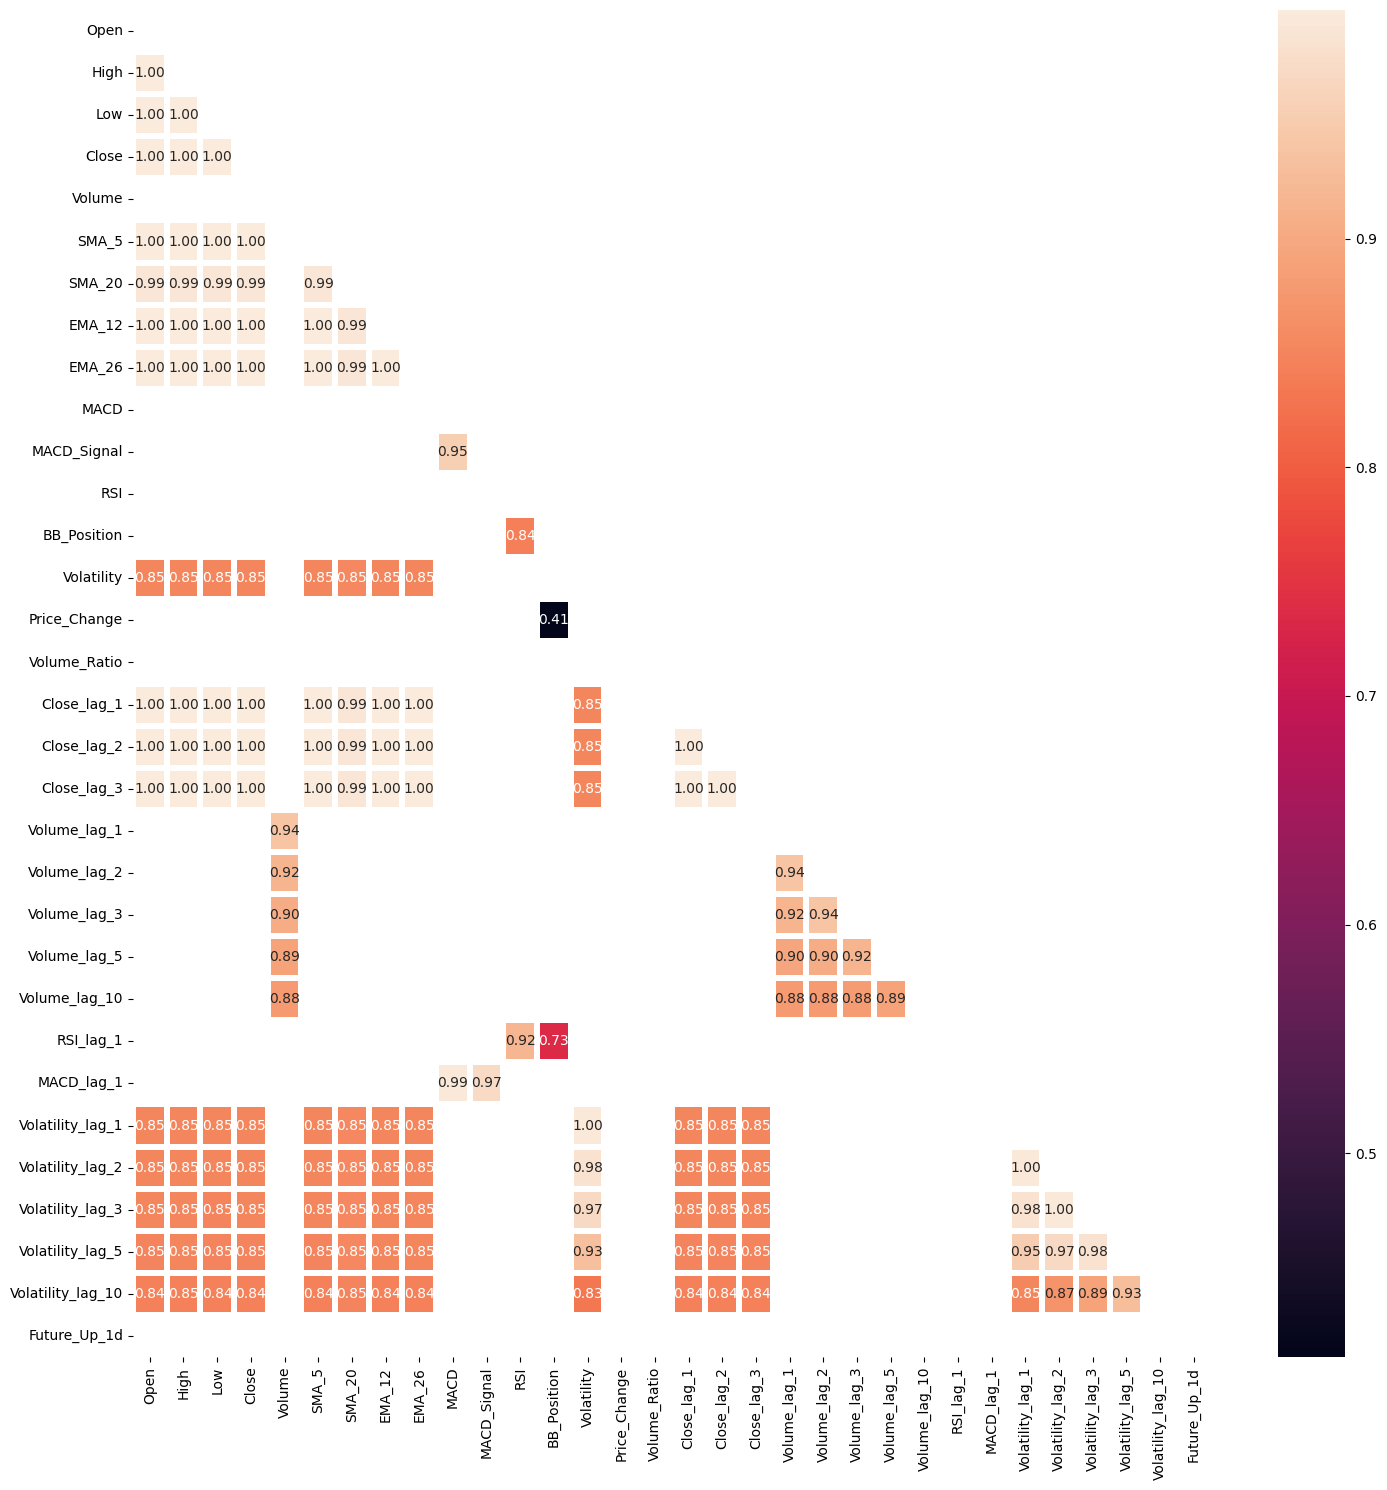

In [ ]:
# Create a DataFrame with only numeric columns (excluding 'Ticker')
df_filtrado = df.drop(columns=['Ticker'])

# Compute the correlation matrix for numeric variables
corr_numerical = df_filtrado.corr(numeric_only=True)

# Filter strong correlations and prepare the upper-triangle mask
high_correlation = corr_numerical[corr_numerical.abs() > 0.40]
mask = np.triu(np.ones_like(corr_numerical, dtype=bool))

# Plot the heatmap of correlations
fig, axis = plt.subplots(figsize=(15, 15))
sns.heatmap(high_correlation, annot=True, mask=mask, linewidths=3, fmt='.2f')

plt.tight_layout()
plt.show()

In [ ]:
# Remove highly redundant columns identified in the correlation heatmap
cols_to_drop = ['Open', 'High', 'Low', 'SMA_5', 'SMA_20', 'EMA_26', 'Close_lag_1', 'Close_lag_2',
                'Close_lag_3', 'Volatility_lag_2', 'Volatility_lag_3', 'Volatility_lag_5', 'Volatility_lag_10']

df = df.drop(columns=cols_to_drop)

### Observations
These columns were removed because they showed very high correlations (0.85 or higher) with other variables, indicating redundancy and potential multicollinearity. None of them had a direct relationship with the target Future_Up_1d, so dropping them simplifies the dataset without losing relevant information for modeling.

In [ ]:
# Check how the target 'Future_Up_1d' relates to next day's price change
verificacion = df[['Ticker', 'Price_Change', 'Future_Up_1d']].copy()
verificacion['Next_Day_Change'] = verificacion.groupby('Ticker')['Price_Change'].shift(-1)

In [ ]:
# Calculate the average change when the target is 1
verificacion[verificacion['Future_Up_1d'] == 1]['Next_Day_Change'].mean()

np.float64(0.014186315330177637)

### Conclusion
The results show that the average change when Future_Up_1d is 1 is approximately 0.014 (1.41%). This confirms that our target variable correctly captures the significant upward movements we aim to predict.

## Train / Test Split

In [ ]:
# Define X (features) and y (target)
X = df.drop(columns = ['Future_Up_1d'])
y = df['Future_Up_1d']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Target Encoding

The problem is that the 'Ticker' column contains thousands of different stock symbols. Using OneHotEncoder creates a separate column for each company, producing a massive, sparse matrix that can overwhelm the model.

By using Target Encoding, each stock symbol is replaced with the average probability that the target variable is one for that company. This reduces the dataset from tens of thousands of columns to a single numeric column.

This approach improves the model for several reasons. First, it drastically reduces dimensionality, making the model more efficient and preventing memory issues. Second, it provides a direct signal to the model, representing the likelihood that a stock will rise based on its historical performance. Third, it allows the model to capture similarities between stocks, as those with comparable behavior receive similar values, improving generalization.

In [ ]:
# Separate numeric features and encode the ticker using Target Encoding
X_train_num = X_train.drop(columns=['Ticker'])
X_test_num = X_test.drop(columns=['Ticker'])

target_encoder = TargetEncoder(cols=['Ticker'])

# Encode the 'Ticker' column into numeric values
X_train_ticker_encoded = target_encoder.fit_transform(X_train[['Ticker']], y_train)
X_test_ticker_encoded = target_encoder.transform(X_test[['Ticker']])

# Concatenate numeric features with the encoded ticker
X_train_final = pd.concat([X_train_num, X_train_ticker_encoded], axis=1)
X_test_final = pd.concat([X_test_num, X_test_ticker_encoded], axis=1)

Columnas finales: ['Close', 'Volume', 'EMA_12', 'MACD', 'MACD_Signal', 'RSI', 'BB_Position', 'Volatility', 'Price_Change', 'Volume_Ratio', 'Volume_lag_1', 'Volume_lag_2', 'Volume_lag_3', 'Volume_lag_5', 'Volume_lag_10', 'RSI_lag_1', 'MACD_lag_1', 'Volatility_lag_1', 'Ticker']
Forma final: (496076, 19)


## Standard Scaler

In [ ]:
# Standard Scaler
scaler = StandardScaler()
scaler.fit(X_train_final)
X_train_scaled_array = scaler.transform(X_train_final)
X_test_scaled_array  = scaler.transform(X_test_final)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=X_train_final.columns, index=X_train_final.index)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=X_test_final.columns, index=X_test_final.index)

# Check the result
X_train_scaled.head()

,Close,Volume,EMA_12,MACD,MACD_Signal,RSI,BB_Position,Volatility,Price_Change,Volume_Ratio,Volume_lag_1,Volume_lag_2,Volume_lag_3,Volume_lag_5,Volume_lag_10,RSI_lag_1,MACD_lag_1,Volatility_lag_1,Ticker
408825,-0.380669,-0.114371,-0.381464,-0.144015,-0.142860,-0.487718,-0.273116,-0.391580,1.202804,0.008500,0.228441,-0.174430,-0.165565,-0.122083,-0.160240,-0.746431,-0.152547,-0.386861,1.004365
402236,0.587076,-0.237913,0.594905,-0.354218,-0.203882,-0.670871,-0.562118,0.682685,-0.713135,-0.834092,-0.235938,-0.227419,-0.231011,-0.219459,-0.221224,-0.593984,-0.356049,0.672586,0.883659
414148,-0.424226,-0.239188,-0.425759,-0.068211,-0.095325,0.907671,0.893836,-0.417595,0.786658,-0.517921,-0.246335,-0.251104,-0.248118,-0.248984,-0.184570,0.592807,-0.073208,-0.420233,-0.098392
217821,0.083941,-0.249402,0.106602,-0.794370,-0.684194,-2.057810,-1.369593,0.228762,-0.626808,-0.783239,-0.246121,-0.245544,-0.242012,-0.249676,-0.239564,-1.883802,-0.748959,0.204417,0.564941
277849,0.208720,-0.182733,0.218245,0.148481,0.315525,-0.675328,-1.010406,-0.237081,0.045244,0.267677,-0.187801,-0.197584,-0.211273,-0.209603,-0.204029,-0.332931,0.203573,-0.238646,0.962274


## Save Train and Test data

In [ ]:
# Save the processed training and testing datasets (features and target) as CSV files
X_train_scaled.to_csv('../data/processed/X_train_eda1.csv', index = False)
X_test_scaled.to_csv('../data/processed/X_test_eda1.csv', index = False)
y_train.to_csv('../data/processed/y_train_eda1.csv', index = False)
y_test.to_csv('../data/processed/y_test_eda1.csv', index = False)